In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import re

import shap

from lime.lime_text import LimeTextExplainer

from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import load_model

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
df = pd.read_csv("../datasets/resume_dataset.csv")

df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \nMay 2013 to May 2017 B.E ...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \n MCA YMCAUST, Faridabad..."


In [3]:
def clean_text(text):

    text = str(text)

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"&\w+;", " ", text)

    text = re.sub(r"[^a-zA-Z ]", " ", text)

    text = text.lower()

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [4]:
df["clean_resume"] = df["Resume"].apply(clean_text)

df.head()

,Category,Resume,clean_resume
0,Data Science,Skills * Programming Languages: Python (pandas...,skills programming languages python pandas num...
1,Data Science,Education Details \nMay 2013 to May 2017 B.E ...,education details may to may b e uit rgpvdata ...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",areas of interest deep learning control system...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skills r python sap hana tableau sap hana sql ...
4,Data Science,"Education Details \n MCA YMCAUST, Faridabad...",education details mca ymcaust faridabad haryan...


In [5]:
encoder = LabelEncoder()

encoder.fit(df["Category"])

num_classes = len(

    encoder.classes_
)

print(

    encoder.classes_
)

['Advocate' 'Arts' 'Automation Testing' 'Blockchain' 'Business Analyst'
 'Civil Engineer' 'Data Science' 'Database' 'DevOps Engineer'
 'DotNet Developer' 'ETL Developer' 'Electrical Engineering' 'HR' 'Hadoop'
 'Health and fitness' 'Java Developer' 'Mechanical Engineer'
 'Network Security Engineer' 'Operations Manager' 'PMO' 'Python Developer'
 'SAP Developer' 'Sales' 'Testing' 'Web Designing']


In [6]:
vocab_size = 5000

max_length = 400

tokenizer = Tokenizer(

    num_words=vocab_size,

    oov_token="<OOV>"
)

tokenizer.fit_on_texts(

    df["clean_resume"]
)

In [7]:
model = load_model(

    "../Task2_DeepLearning/resume_classifier.keras"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 400, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │           825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,043,213 (3.98 MB)

 Trainable params: 347,737 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 695,476 (2.65 MB)

In [8]:
def predict_proba(texts):

    sequences = tokenizer.texts_to_sequences(

        texts
    )

    padded = pad_sequences(

        sequences,

        maxlen=max_length,

        padding="post",

        truncating="post"
    )

    return model.predict(

        padded,

        verbose=0
    )

In [9]:
explainer = LimeTextExplainer(

    class_names=encoder.classes_
)

In [10]:
sample = df["clean_resume"].iloc[0]

sample

'skills programming languages python pandas numpy scipy scikit learn matplotlib sql java javascript jquery machine learning regression svm na ve bayes knn random forest decision trees boosting techniques cluster analysis word embedding sentiment analysis natural language processing dimensionality reduction topic modelling lda nmf pca neural nets database visualizations mysql sqlserver cassandra hbase elasticsearch d js dc js plotly kibana matplotlib ggplot tableau others regular expression html css angular logstash kafka python flask git docker computer vision open cv and understanding of deep learning education details data science assurance associatedata science assurance associate ernst young llpskill details javascript exprience months jquery exprience months python exprience monthscompany details company ernst young llp description fraud investigations and dispute services assurance technology assisted review tar technology assisted review assists in accelerating the review proces

In [11]:
exp = explainer.explain_instance(

    sample,

    predict_proba,

    num_features=10
)

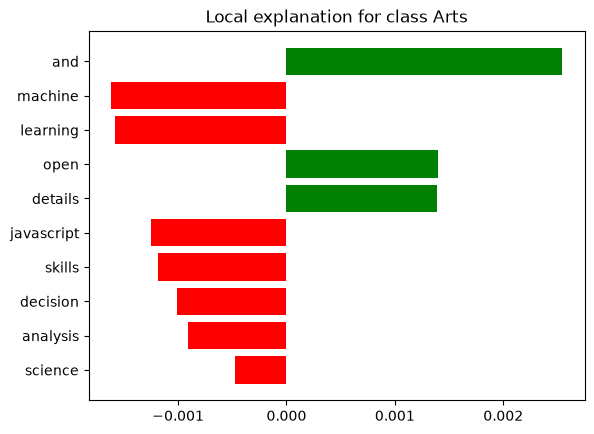

In [12]:
fig = exp.as_pyplot_figure()

plt.show()

In [13]:
distribution = df["Category"].value_counts()

distribution

Category
Java Developer               14
HR                           11
Database                     11
Data Science                 10
Advocate                     10
Automation Testing            7
DevOps Engineer               7
Hadoop                        7
DotNet Developer              7
Testing                       7
Arts                          6
Health and fitness            6
Civil Engineer                6
Business Analyst              6
SAP Developer                 6
Python Developer              6
Web Designing                 5
Mechanical Engineer           5
Sales                         5
Electrical Engineering        5
Network Security Engineer     5
ETL Developer                 5
Blockchain                    5
Operations Manager            4
PMO                           3
Name: count, dtype: int64

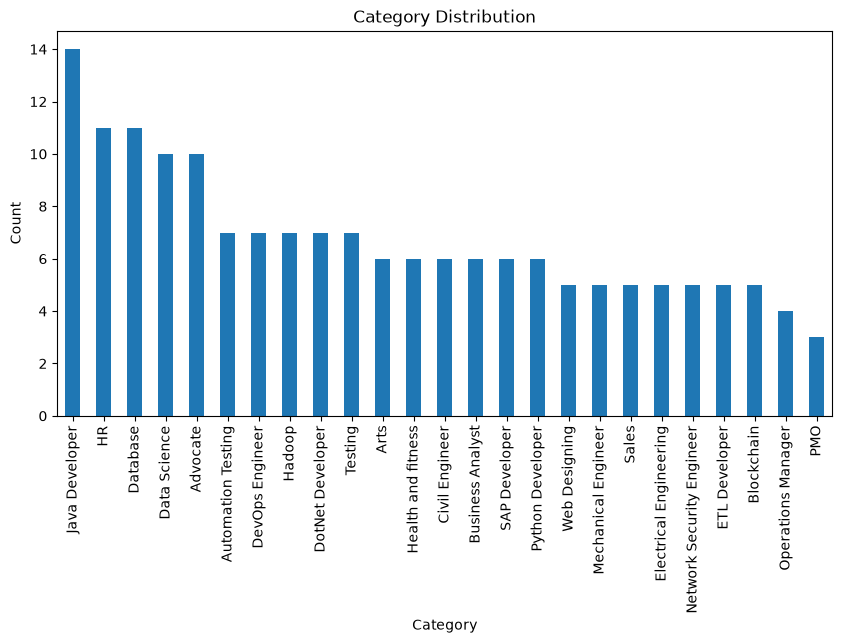

In [14]:
distribution.plot(

    kind="bar",

    figsize=(10,5)
)

plt.title(

    "Category Distribution"
)

plt.xlabel(

    "Category"
)

plt.ylabel(

    "Count"
)

plt.xticks(

    rotation=90
)

plt.show()

In [15]:
mitigation = [

"Collect more resumes",

"Balance dataset",

"Remove sensitive attributes",

"Use stratified splitting",

"Perform fairness evaluation regularly"

]

for item in mitigation:

    print(item)

Collect more resumes
Balance dataset
Remove sensitive attributes
Use stratified splitting
Perform fairness evaluation regularly
